**Import all libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


**Uploaded dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving habit_dataset_final.csv to habit_dataset_final (9).csv


**Perform initial exploration**

In [ ]:
df = pd.read_csv(
    "habit_dataset_final.csv"
)

df.head(5)

,User_ID,Date,Sleep Duration (Hours),Sleep Quality,Bedtime,Wake-up,Study/Work,Productivity Level,Exercise(Minutes),Exercise Type,Screen Time,Primary Screen Activity,Mood Score,Stress Level,Caffeine Intake (Liters),Water Intake (Liters),Habit_Score,Day_Number,Drift_Score
0,User_01,27/06/2026,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,10,7,2.0,2.0,51.708333,1,0.0
1,User_01,28/06/2026,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,6,7,2.0,2.0,45.708333,2,-6.0
2,User_01,29/06/2026,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,7,7,2.0,2.0,47.208333,3,1.5
3,User_01,30/06/2026,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,5,7,2.0,2.0,44.208333,4,-3.0
4,User_01,01/07/2026,8.0,10,23:50:00,07:55:00,5.0,5,10,Waliking,3.0,Mixed Usage,6,6,1.0,2.0,55.708333,5,11.5


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.info()

Dataset Shape:
(240, 19)

Columns:
['User_ID', 'Date', 'Sleep Duration (Hours)', 'Sleep Quality', 'Bedtime', 'Wake-up', 'Study/Work', 'Productivity Level', 'Exercise(Minutes)', 'Exercise Type', 'Screen Time', 'Primary Screen Activity', 'Mood Score', 'Stress Level', 'Caffeine Intake (Liters)', 'Water Intake (Liters)', 'Habit_Score', 'Day_Number', 'Drift_Score']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   240 non-null    object 
 1   Date                      240 non-null    object 
 2   Sleep Duration (Hours)    240 non-null    float64
 3   Sleep Quality             240 non-null    int64  
 4   Bedtime                   240 non-null    object 
 5   Wake-up                   240 non-null    object 
 6   Study/Work                240 non-null    float64
 7   Productivity Level        240 no

In [ ]:
#Check missing values
df['Exercise Type'] = df['Exercise Type'].fillna('None')

df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

df.isnull().sum()

,0
User_ID,0
Date,0
Sleep Duration (Hours),0
Sleep Quality,0
Bedtime,0
Wake-up,0
Study/Work,0
Productivity Level,0
Exercise(Minutes),0
Exercise Type,0


**Date Formatting**

In [ ]:
df['Date'] = pd.to_datetime(
    df['Date']
)
df = df.sort_values(
    [
        'User_ID',
        'Date'
    ]
)

df.head()

,User_ID,Date,Sleep Duration (Hours),Sleep Quality,Bedtime,Wake-up,Study/Work,Productivity Level,Exercise(Minutes),Exercise Type,Screen Time,Primary Screen Activity,Mood Score,Stress Level,Caffeine Intake (Liters),Water Intake (Liters),Habit_Score,Day_Number,Drift_Score
0,User_01,2026-06-27,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,10,7,2.0,2.0,51.708333,1,0.0
1,User_01,2026-06-28,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,6,7,2.0,2.0,45.708333,2,-6.0
2,User_01,2026-06-29,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,7,7,2.0,2.0,47.208333,3,1.5
3,User_01,2026-06-30,6.0,6,00:00:00,07:25:00,5.0,6,10,Waliking,6.0,Mixed Usage,5,7,2.0,2.0,44.208333,4,-3.0
4,User_01,2026-07-01,8.0,10,23:50:00,07:55:00,5.0,5,10,Waliking,3.0,Mixed Usage,6,6,1.0,2.0,55.708333,5,11.5


**Remove Unnecessary Columns**

In [ ]:
# Remove target and shortcut features

features = [
    'Sleep Duration (Hours)',
    'Sleep Quality',
    'Study/Work',
    'Productivity Level',
    'Exercise(Minutes)',
    'Screen Time',
    'Mood Score',
    'Stress Level',
    'Caffeine Intake (Liters)',
    'Water Intake (Liters)'
]
X = df[features]
y = df['Drift_Score']

print("Number of features:", len(features))
print("Dataset shape:", X.shape)

Number of features: 10
Dataset shape: (240, 10)


**Train-Test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(192, 10)
(48, 10)


**Machine Learning Models**

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}
print("Models ready")

Models ready


**Models Results**

In [ ]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    mae = mean_absolute_error(
        y_test,
        prediction
    )
    mse = mean_squared_error(
        y_test,
        prediction
    )
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_test,
        prediction
    )
    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.907188,57.407259,7.576758,0.128292
1,Random Forest,6.056633,54.698893,7.395870,0.169417
2,Gradient Boosting,6.060567,55.034594,7.418530,0.164320


**Select Best Model**

In [ ]:
# Select Gradient Boosting as the final model
best_model_name = "Gradient Boosting"
best_model = models[best_model_name]
print("Final ML Model:", best_model_name)

Final ML Model: Gradient Boosting


**Train Best Model**

In [ ]:
best_model.fit(
    X_train,
    y_train
)
print("Gradient Boosting model trained successfully")

Gradient Boosting model trained successfully


**Test Best Model Prediction**

In [ ]:
best_prediction = best_model.predict(
    X_test
)
comparison = pd.DataFrame({
    "Actual Drift Score": y_test.values,
    "Predicted Drift Score": best_prediction
})

display(comparison.head(10))

,Actual Drift Score,Predicted Drift Score
0,-0.770833,6.184959
1,-7.750000,0.566377
2,5.145833,-0.588989
3,-22.729167,-13.735993
4,1.354167,0.734433
5,0.000000,6.526331
6,5.416667,6.188230
7,-1.750000,1.970826
8,12.583333,-0.454895
9,0.000000,-4.255289


**Visualize Prediction Performance**

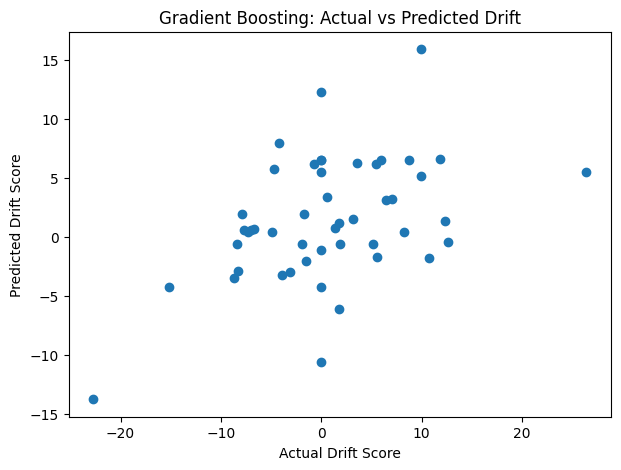

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    best_prediction
)

plt.xlabel("Actual Drift Score")
plt.ylabel("Predicted Drift Score")
plt.title("Gradient Boosting: Actual vs Predicted Drift")

plt.show()

**Save Model**

In [ ]:
joblib.dump(
    best_model,
    "habit_drift_model.pkl"
)

print("Gradient Boosting model saved successfully")

Gradient Boosting model saved successfully


**Feature Importance**

In [ ]:
importance_values = best_model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance_values
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
display(feature_importance)

,Feature,Importance
7,Stress Level,0.165706
0,Sleep Duration (Hours),0.163718
3,Productivity Level,0.156849
6,Mood Score,0.130086
5,Screen Time,0.105135
4,Exercise(Minutes),0.088559
1,Sleep Quality,0.058493
2,Study/Work,0.058042
8,Caffeine Intake (Liters),0.046143
9,Water Intake (Liters),0.027268


**Feature Importance Graph**

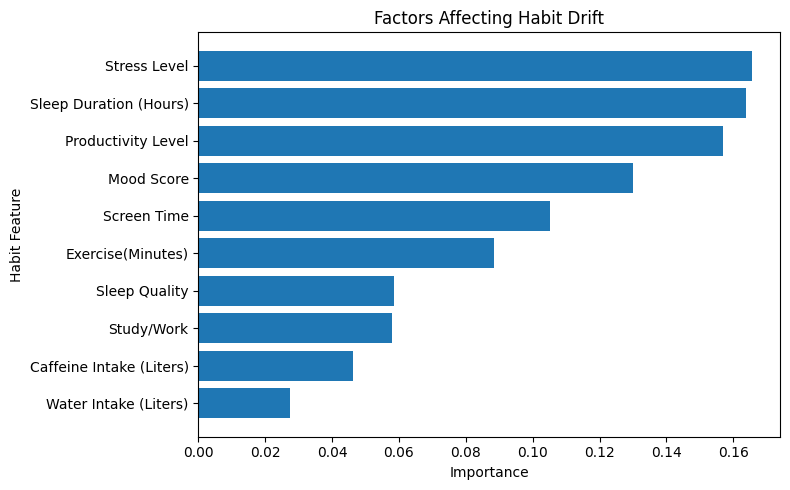

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Habit Feature")
plt.title("Factors Affecting Habit Drift")

plt.tight_layout()
plt.show()

In [ ]:
#Save feature importance
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved")

Feature importance saved


**Calculate user's normal habit level**

In [ ]:
habit_features = [
    'Sleep Duration (Hours)',
    'Study/Work',
    'Productivity Level',
    'Exercise(Minutes)',
    'Screen Time',
    'Mood Score'
]
for feature in habit_features:
    df[feature + '_Baseline'] = (
        df.groupby('User_ID')[feature]
        .transform('mean')
    )
print("Personal baselines created")

Personal baselines created


**Calculate Habit Change**

In [ ]:
for feature in habit_features:
    df[feature + '_Change'] = (
        df[feature] -
        df[feature + '_Baseline']
    )

print("Habit changes calculated")

Habit changes calculated


**Drift Status**

In [ ]:
def get_drift_status(score):
    if score > 0.10:
        return "Improving"
    elif score < -0.10:
        return "Declining"
    else:
        return "Stable"
df["Drift_Status"] = df["Drift_Score"].apply(
    get_drift_status
)
display(
    df[
        [
            "User_ID",
            "Date",
            "Drift_Score",
            "Drift_Status"
        ]
    ].head(10)
)

,User_ID,Date,Drift_Score,Drift_Status
0,User_01,2026-06-27,0.000000,Stable
1,User_01,2026-06-28,-6.000000,Declining
2,User_01,2026-06-29,1.500000,Improving
3,User_01,2026-06-30,-3.000000,Declining
4,User_01,2026-07-01,11.500000,Improving
5,User_01,2026-07-02,3.750000,Improving
6,User_01,2026-07-03,-7.750000,Declining
7,User_01,2026-07-04,-21.833333,Declining
8,User_01,2026-07-05,5.250000,Improving
9,User_01,2026-07-06,12.583333,Improving


**For any user**

In [ ]:
print(df["User_ID"].unique())

['User_01' 'User_02' 'User_03' 'User_04' 'User_05' 'User_06' 'User_07'
 'User_08']


In [ ]:
selected_user = input("Enter User ID: ")
user_data = df[
    df["User_ID"] == selected_user
].sort_values("Date")

if user_data.empty:
    print("User not found.")
else:
    print("Analyzing:", selected_user)

    # Get the latest record
    latest = user_data.iloc[-1]
    display(
        user_data[
            [
                "Date",
                "Drift_Score",
                "Drift_Status"
            ]
        ]
    )

Enter User ID: User_01
Analyzing: User_01


,Date,Drift_Score,Drift_Status
0,2026-06-27,0.000000,Stable
1,2026-06-28,-6.000000,Declining
2,2026-06-29,1.500000,Improving
3,2026-06-30,-3.000000,Declining
4,2026-07-01,11.500000,Improving
5,2026-07-02,3.750000,Improving
6,2026-07-03,-7.750000,Declining
7,2026-07-04,-21.833333,Declining
8,2026-07-05,5.250000,Improving
9,2026-07-06,12.583333,Improving


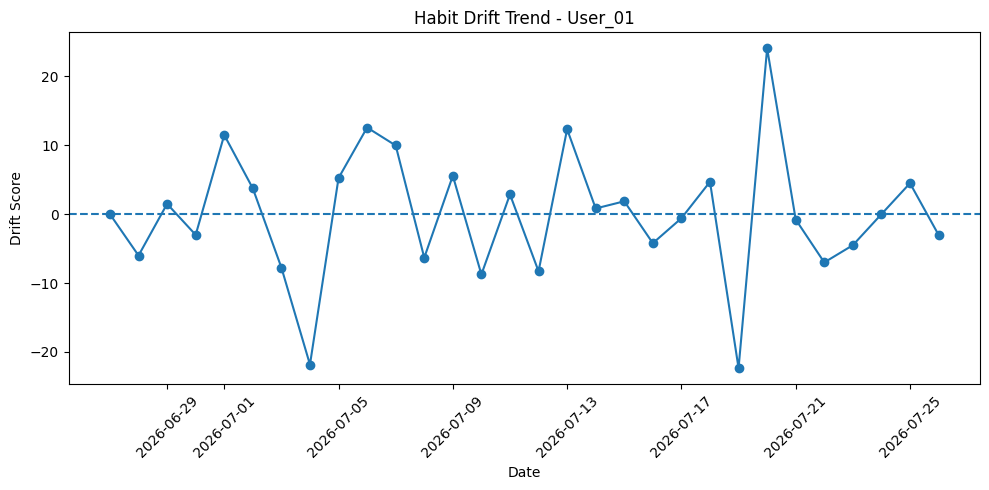

In [ ]:
if not user_data.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(
        user_data["Date"],
        user_data["Drift_Score"],
        marker="o"
    )
    plt.axhline(
        y=0,
        linestyle="--"
    )
    plt.xlabel("Date")
    plt.ylabel("Drift Score")
    plt.title(
        f"Habit Drift Trend - {selected_user}"
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Early Warning System**

In [ ]:
def check_warning(user_data):
    recent_scores = user_data[
        "Drift_Score"
    ].tail(5)
    declining_days = sum(
        recent_scores < -0.10
    )
    if declining_days >= 4:
        return "HIGH WARNING: Negative drift detected consistently."
    elif declining_days >= 2:
        return "WARNING: Recent negative drift detected."
    else:
        return "No early warning detected."
warning = check_warning(user_data)
print("Early Warning:")
print(warning)

Early Warning:


**Prepare Forecast Data**

In [ ]:
# Prepare previous Drift Scores
forecast_data = user_data[
    ["Date", "Drift_Score"]
].copy()
forecast_data["Previous_1"] = (
    forecast_data["Drift_Score"].shift(1)
)
forecast_data["Previous_2"] = (
    forecast_data["Drift_Score"].shift(2)
)
forecast_data["Previous_3"] = (
    forecast_data["Drift_Score"].shift(3)
)
forecast_data = forecast_data.dropna()
print("Forecast data prepared")
display(forecast_data.head())

Forecast data prepared


,Date,Drift_Score,Previous_1,Previous_2,Previous_3
3,2026-06-30,-3.000000,1.50,-6.00,0.0
4,2026-07-01,11.500000,-3.00,1.50,-6.0
5,2026-07-02,3.750000,11.50,-3.00,1.5
6,2026-07-03,-7.750000,3.75,11.50,-3.0
7,2026-07-04,-21.833333,-7.75,3.75,11.5


**Train the Forecasting Model**

In [ ]:
forecast_features = [
    "Previous_1",
    "Previous_2",
    "Previous_3"
]
X_forecast = forecast_data[
    forecast_features
]
y_forecast = forecast_data[
    "Drift_Score"
]
forecast_model = GradientBoostingRegressor(
    random_state=42
)
forecast_model.fit(
    X_forecast,
    y_forecast
)
print("Gradient Boosting forecasting model trained successfully")

Gradient Boosting forecasting model trained successfully


**Future Drift Prediction**

In [ ]:
# Predict the next day's Drift Score
last_three = user_data[
    "Drift_Score"
].tail(3).values
future_input = pd.DataFrame({
    "Previous_1": [last_three[2]],
    "Previous_2": [last_three[1]],
    "Previous_3": [last_three[0]]
})
future_drift = forecast_model.predict(
    future_input
)[0]
print(
    "Predicted Future Drift:",
    round(future_drift, 3)
)

Predicted Future Drift: 0.615


**Convert Forecast into Meaning**

In [ ]:
if future_drift > 0.10:
    future_status = "Improving"
elif future_drift < -0.10:
    future_status = "Declining"
else:
    future_status = "Stable"
print(
    "Predicted Future Status:",
    future_status
)

Predicted Future Status: Improving


**Forecast Visualization**

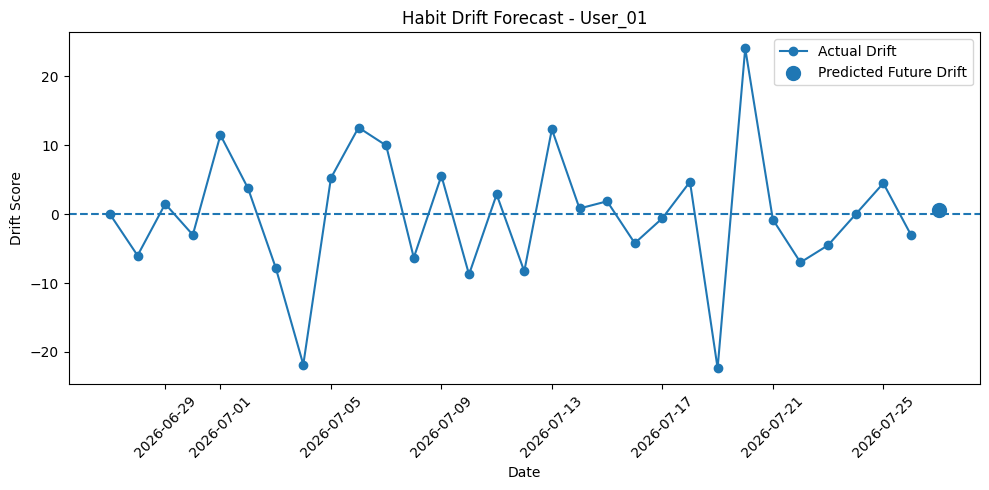

In [ ]:
next_date = (
    user_data["Date"].iloc[-1]
    + pd.Timedelta(days=1)
)
plt.figure(figsize=(10, 5))
plt.plot(
    user_data["Date"],
    user_data["Drift_Score"],
    marker="o",
    label="Actual Drift"
)
plt.scatter(
    next_date,
    future_drift,
    s=100,
    label="Predicted Future Drift"
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Date")
plt.ylabel("Drift Score")
plt.title(
    f"Habit Drift Forecast - {selected_user}"
)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Personalized Habit Analysis**

In [ ]:
print("Personalized Habit Analysis")
print("---------------------------")
positive_habits = [
    'Sleep Duration (Hours)',
    'Study/Work',
    'Productivity Level',
    'Exercise(Minutes)',
    'Mood Score'
]
for feature in positive_habits:
    change = (
        latest[feature]
        - latest[feature + "_Baseline"]
    )
    if change < 0:
        print(
            "↓",
            feature,
            "is lower than the personal baseline."
        )
    elif change > 0:
        print(
            "↑",
            feature,
            "is higher than the personal baseline."
        )
    else:
        print(
            "→",
            feature,
            "is at the personal baseline."
        )
screen_change = (
    latest["Screen Time"]
    - latest["Screen Time_Baseline"]
)
if screen_change > 0:
    print(
        "↑ Screen Time is higher than the personal baseline."
    )
elif screen_change < 0:
    print(
        "↓ Screen Time is lower than the personal baseline."
    )
else:
    print(
        "→ Screen Time is at the personal baseline."
    )

Personalized Habit Analysis
---------------------------
↓ Sleep Duration (Hours) is lower than the personal baseline.
↓ Study/Work is lower than the personal baseline.
↓ Productivity Level is lower than the personal baseline.
↑ Exercise(Minutes) is higher than the personal baseline.
↑ Mood Score is higher than the personal baseline.
↑ Screen Time is higher than the personal baseline.


**Overall Habit Condition**

In [ ]:
positive_changes = 0
negative_changes = 0
for feature in positive_habits:
    change = (
        latest[feature]
        - latest[feature + "_Baseline"]
    )
    if change > 0:
        positive_changes += 1
    elif change < 0:
        negative_changes += 1
if screen_change > 0:
    negative_changes += 1
elif screen_change < 0:
    positive_changes += 1
if negative_changes >= 5:
    habit_condition = "Needs Attention"
elif negative_changes >= 3:
    habit_condition = "Moderate"
else:
    habit_condition = "Generally Stable"
print("Overall Habit Condition:", habit_condition)

Overall Habit Condition: Moderate


**Final Habit Report**

In [ ]:
print("\nRecommendation:")
negative_habits_found = []
for feature in positive_habits:
    change = (
        latest[feature]
        - latest[feature + "_Baseline"]
    )
    if change < 0:
        negative_habits_found.append(feature)
if screen_change > 0:
    negative_habits_found.append(
        "Screen Time"
    )
if future_status == "Declining":
    print(
        "The model predicts a negative drift in the near future."
    )
    if negative_habits_found:
        print("Pay attention to:")
        for feature in negative_habits_found:
            print("-", feature)
elif habit_condition == "Needs Attention":
    print(
        "Several habits are moving away from the personal baseline."
    )
    print("Pay attention to:")
    for feature in negative_habits_found:
        print("-", feature)
elif habit_condition == "Moderate":
    print(
        "Some habits have changed from the personal baseline."
    )
    if negative_habits_found:
        print("Monitor:")
        for feature in negative_habits_found:
            print("-", feature)
else:
    print(
        "Your current habit pattern is generally stable."
    )
    print(
        "Continue maintaining your current routine."
    )


Recommendation:
Some habits have changed from the personal baseline.
Monitor:
- Sleep Duration (Hours)
- Study/Work
- Productivity Level
- Screen Time
